# Problem 1: Members of German Parliament

In [1]:
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from matplotlib.lines import Line2D

# Constants for data cleaning:
BASE = 'https://raw.githubusercontent.com/jolyphil/btmembers/main/csv/'
FACTION_MAP = {
    'Fraktion der SPD (Gast)': 'SPD',
    'Fraktion der Sozialdemokratischen Partei Deutschlands': 'SPD',
    'Fraktion der FDP (Gast)': 'FDP',
    'Fraktion der Freien Demokratischen Partei': 'FDP',
    'Fraktion Die Grünen': 'GRÜNE',
    'Fraktion Die Grünen/Bündnis 90': 'GRÜNE',
    'Fraktion BÜNDNIS 90/DIE GRÜNEN': 'GRÜNE',
    'Gruppe Bündnis 90/Die Grünen': 'GRÜNE',
    'Gruppe der Partei des Demokratischen Sozialismus/Linke Liste': 'PDS',
    'Gruppe der Partei des Demokratischen Sozialismus': 'PDS',
    'Fraktion der Partei des Demokratischen Sozialismus': 'PDS',
    'Fraktion Die Linke': 'DIE LINKE',
    'Fraktion DIE LINKE.': 'DIE LINKE',
    'Gruppe Die Linke': 'DIE LINKE',
    'Fraktion Alternative für Deutschland': 'AfD',
}
CDU_CSU_FACTIONS = {
    'Fraktion der CDU/CSU (Gast)',
    'Fraktion der Christlich Demokratischen Union/Christlich - Sozialen Union',
}
TODAY = pd.Timestamp('2026-07-25')

# Constants for plotting:
DEFAULT_SHADES = ['#f2f2f2', '#999999', '#333333']
DEFAULT_TEXT_COLORS = ['black', 'white', 'white']
PARTY_ORDER = ['PDS', 'DIE LINKE', 'SPD', 'GRÜNE', 'FDP', 'CDU', 'CSU', 'AfD', 'OTHER']
PARTY_COLOURS = ['purple', '#BE3075', '#E3000F', '#1AA037', '#FFEF00', '#000000', '#0570C9', '#5B3626', 'grey']
PARTY_DICT = dict(zip(PARTY_ORDER, PARTY_COLOURS))
GENDER_MARKERS = {
    'male': 's',
    'female': 'o',
    'diverse': '^'
}
GENDER_OFFSETS = {
    'female': 0.15,
    'diverse': 0.0,
    'male': -0.15
}

## 1.1 Storing the data
We store the raw data in two DataFrames: mdb_df for members of parliament and information about them and wp_df with an entry for each term a MDB served with the corresponding start and end dates.
From the latter we derive a terms_df that only stores the general term dates for plotting.

In [2]:
def safe_merge(df1, df2, key):
    """
    Merge two dataframes with a key, making sure not to create duplicate columns.
    :param df1: DataFrame to be enlarged.
    :param df2: DataFrame to be merged.
    :param key: List of column(s) to be used as a key.
    :return: DataFrame with merged columns.
    """
    for column in df2.columns:
        if column not in key and column in df1.columns:
            df1 = df1.drop(columns=column)
    return df1.merge(df2, on=key, how='left')

def categorize_title(title):
    """
    Categorizes academic titles into Prof., Dr., and No title.
    :param title: str
    :return: str: Prof., Dr., or No title.
    """
    title = title.strip()
    if title.startswith('Prof'):
        return 'Prof.'
    elif title.startswith('Dr'):
        return 'Dr.'
    else:
        return 'No title'

In [3]:
# Accessing the XML file:
xml_path = './data_bundestag/mdb-data.xml'
tree = ET.parse(xml_path)
root = tree.getroot()

# Storing mdb data:
mdb_data = []
for mdb in root.findall('MDB'):
    info = mdb.find('INFO')
    mdb = {
        'ID': info.findtext('ID'),
        'First_name': info.findtext('First_name'),
        'Last_name': info.findtext('Last_name'),
        'Acad_Title': info.findtext('Acad_Title'),
        'Date_of_birth': info.findtext('Date_of_birth'),
        'Gender': info.findtext('Gender'),
        'Party': info.findtext('Party'),
        'Marital_status': info.findtext('Marital_status'),
        'Children': info.findtext('Children'),
    }
    mdb_data.append(mdb)
mdb_df = pd.DataFrame(mdb_data)

# Converting data types:
mdb_df['ID'] = mdb_df['ID'].astype(int)
mdb_df['Date_of_birth'] = pd.to_datetime(mdb_df['Date_of_birth'])
mdb_df['Children'] = mdb_df['Children'].astype(int)
mdb_df['Gender'] = mdb_df['Gender'].astype('category')
mdb_df['Party'] = mdb_df['Party'].astype('category')
mdb_df['Marital_status'] = mdb_df['Marital_status'].astype('category')
mdb_df['Marital_status'] = mdb_df['Marital_status'].cat.rename_categories({
    'no information / other': 'No information',
    'with partner': 'With partner',
    'married': 'Married',
})
mdb_df['Acad_Title'] = mdb_df['Acad_Title'].apply(categorize_title).astype('category')

# Storing wp data:
wp_data = []
for mdb in root.findall('MDB'):
    id = mdb.find('INFO').findtext('ID')
    wplist = mdb.find('WPLIST')
    for wp in wplist.findall('WP'):
        wp_entry = {
            'ID': int(id),
            'WP': int(wp.findtext('WP')),
            'MDBWP_FROM': wp.findtext('MDBWP_FROM'),
            'MDBWP_UNTIL': wp.findtext('MDBWP_UNTIL'),
            'WP_BEGIN': wp.findtext('WP_BEGIN'),
        }
        wp_data.append(wp_entry)
wp_df = pd.DataFrame(wp_data)

# Converting data types:
wp_df['MDBWP_FROM'] = pd.to_datetime(wp_df['MDBWP_FROM'])
wp_df['MDBWP_UNTIL'] = wp_df['MDBWP_UNTIL'].apply(
    lambda x: pd.to_datetime(x) if x != '/' else pd.NaT
)   # Handling open-ended dates (marked with "/").
wp_df['WP_BEGIN'] = pd.to_datetime(wp_df['WP_BEGIN'])

# Creating a terms data frame:
terms_df = (
    wp_df[['WP', 'WP_BEGIN']]
    .drop_duplicates(subset='WP')
    .sort_values('WP_BEGIN')
    .reset_index(drop=True)
)
terms_df['election_y_str'] = terms_df['WP_BEGIN'].dt.year.astype(str)
terms_df['election_y_int'] = terms_df['election_y_str'].astype(int)
    # Name election periods after the year they have begun.

mdb_df

,ID,First_name,Last_name,Acad_Title,Date_of_birth,Gender,Party,Marital_status,Children
0,11000001,Manfred,Abelein,Prof.,1930-10-20,male,CDU,No information,0
1,11000002,Ernst,Achenbach,Dr.,1909-04-09,male,FDP,Married,3
2,11000003,Annemarie,Ackermann,No title,1913-05-26,female,CDU,Married,5
3,11000004,Else,Ackermann,Dr.,1933-11-06,female,CDU,No information,0
4,11000005,Ulrich,Adam,No title,1950-06-09,male,CDU,Married,2
...,...,...,...,...,...,...,...,...,...
4609,11005623,Reza,Asghari,Prof.,1961-04-01,male,CDU,Married,2
4610,11005624,Andrea,Lübcke,Dr.,1978-12-09,female,GRÜNE,No information,2
4611,11005625,Lisa,Schubert,No title,2002-09-06,diverse,DIE LINKE,No information,0
4612,11005626,Mayra,Vriesema,No title,1999-12-25,female,GRÜNE,No information,0


## 1.2 Merging MDBs and WPs

To answer the questions, we need to merge MDB data like party membership and gender with WP information. For example, to find out which party was present in parliament at which time.

This merge is producing inconsistencies in the data, as mdb_df only shows the current party membership of the MDB. If an MDB sat the parliament for different parties at different times, this inconsistency causes retrospective party changes that disrespect the linearity of time. One example of an MDB whose entries are affected in such a way is Martin Hohmann, who got excluded from the CDU for his antisemetic speech in 2003. This made him an independent member of parliament, which is handled in our data as OTHER. Martin Hohmann later was reelected in 2017 as a member of the AfD. The merge would therefore show the presence of the AfD in parliament for the early 2000s in which the party did not even exist.

To solve this problem, we need to use external data. Our analysis of the Martin-Hohmann-Inconsistency is therefore based on the preprocessd data from 'https://raw.githubusercontent.com/jolyphil/btmembers/main/csv/' which is based on the official data from the German Bundestag. From this data we extract data of MDBs who are affected and create new rows for wp_df with the corrected entries. Afterwards, we replace the affected rows in wp_df by using name and date of birth as keys. The total number of new rows is 251.

In [4]:
def get_dob(mdb_id):
    """
    Extract the birthdate of an MDB from the additional data source.
    :param mdb_id: int: ID of the MDB in the additional data source.
    :return: pd.dt: Date of birth of the MDB.
    """
    return pd.to_datetime(bio_df.loc[mdb_id, 'geburtsdatum'])

def get_party(mdb_id, ins_long):
    """
    Categorizes the party affiliation of a member of the German Parliament
    based on their ID and the long name of their faction.
    :param mdb_id: int
    :param ins_long: str: long name of the faction
    :return: str: party
    """
    if ins_long in CDU_CSU_FACTIONS:
        party = bio_df.loc[mdb_id, 'partei_kurz'] if mdb_id in bio_df.index else None
        return 'CDU' if party == 'CDU' else 'CSU'
    return FACTION_MAP.get(ins_long, 'OTHER')

def format_date(datum):
    """
    Transforms dates into the format used in the rest of the analysis.
    :param datum: date to be formatted
    :return: pd.dt with standardized nan handling
    """
    return pd.to_datetime(datum.date().isoformat()) if pd.notna(datum) else '/'

# Merging wp_df and mdb_df:
wp_df = safe_merge(wp_df, mdb_df, ['ID'])

# Scraping more data about MDBs that switched parties over time to remove inconsistencies.
factions_df = pd.read_csv(BASE + 'inst.csv', dtype=str)
bio_df = pd.read_csv(BASE + 'bio.csv', dtype=str).set_index('id')
mdb_names_df = pd.read_csv(BASE + 'namen.csv', dtype=str)

# Reducing parliamentary groups to factions only:
factions_df = factions_df[factions_df['insart_lang'] == 'Fraktion/Gruppe'].copy()
factions_df['mdbins_von'] = pd.to_datetime(factions_df['mdbins_von'], errors='coerce')
factions_df['mdbins_bis'] = pd.to_datetime(factions_df['mdbins_bis'], errors='coerce')

# Use full names of the mdbs as primary keys:
mdb_names_df = mdb_names_df.sort_values('historie_von').groupby('id').last()[['nachname', 'vorname']]

# Adding party memberships:
factions_df['party'] = \
    [get_party(id, faction) for id, faction in zip(factions_df['id'], factions_df['ins_lang'])]
factions_df = factions_df.sort_values(['id', 'mdbins_von'])

# Looking for MDBs who sat in the parliament for different parties at different times
# and building personal timelines:
defectors = []
for mdb_id, group in factions_df.groupby('id'):
    group = group.sort_values('mdbins_von')

    # Merging succeeding wps with the same party:
    timeline = []
    for party, start, end in zip(group['party'], group['mdbins_von'], group['mdbins_bis']):
        if timeline and timeline[-1][0] == party:
            timeline[-1] = (party, timeline[-1][1], end)
        else:
            timeline.append((party, start, end))

    # Counting times MDBs switched parties:
    switches = len(timeline) - 1
    if switches == 0:
        continue  # Switching in and out of the same party does not count as a party switch.

    # Adding the MDB to the list of defectors:
    lastn, firstn = mdb_names_df.loc[mdb_id, ['nachname', 'vorname']]
    for i in range(switches):
        defectors.append({
            'First_name': firstn,
            'Last_name': lastn,
            'Date_of_birth': get_dob(mdb_id),
            'Party': timeline[i][0],
            'MDBWP_FROM': format_date(timeline[i][1]),
            'MDBWP_UNTIL': format_date(timeline[i][2])
        })

# Storing results:
defectors_df = pd.DataFrame(defectors)

# Adding WP info:
sorted_defectors_df = defectors_df.sort_values('MDBWP_FROM')
sorted_wp_df = wp_df.sort_values('WP_BEGIN')
wp_defectors_df = pd.merge_asof(
    sorted_defectors_df,
    sorted_wp_df[['WP', 'WP_BEGIN']],
    left_on='MDBWP_FROM',
    right_on='WP_BEGIN',
    direction='backward'
)

# Adding MDB info:
id_lookup = wp_df[['ID', 'First_name', 'Last_name', 'Acad_Title', 'Date_of_birth', 'Gender', 'Marital_status', 'Children']].drop_duplicates(
    subset=['First_name', 'Last_name', 'Date_of_birth'],
)
wp_defectors_df = safe_merge(wp_defectors_df, id_lookup, ['First_name', 'Last_name', 'Date_of_birth'])

# Replace inconsistent entries:
key_cols = ['First_name', 'Last_name','Date_of_birth', 'WP']
mask_to_remove = wp_df.set_index(key_cols).index.isin(
    wp_defectors_df.set_index(key_cols).index
)
wp_df_cleaned = wp_df[~mask_to_remove]
wp_df = pd.concat(
    [wp_df_cleaned, wp_defectors_df],
    ignore_index=True
).sort_values(['ID', 'WP']).reset_index(drop=True)

# Adding term names:
wp_df = safe_merge(wp_df, terms_df, ['WP'])

wp_df

,ID,WP,MDBWP_FROM,MDBWP_UNTIL,First_name,Last_name,Acad_Title,Date_of_birth,Gender,Party,Marital_status,Children,WP_BEGIN,election_y_str,election_y_int
0,11000001,5,1965-10-19,1969-10-19,Manfred,Abelein,Prof.,1930-10-20,male,CDU,No information,0,1965-10-19,1965,1965
1,11000001,6,1969-10-20,1972-09-22,Manfred,Abelein,Prof.,1930-10-20,male,CDU,No information,0,1969-10-20,1969,1969
2,11000001,7,1972-12-13,1976-12-13,Manfred,Abelein,Prof.,1930-10-20,male,CDU,No information,0,1972-12-13,1972,1972
3,11000001,8,1976-12-14,1980-11-04,Manfred,Abelein,Prof.,1930-10-20,male,CDU,No information,0,1976-12-14,1976,1976
4,11000001,9,1980-11-04,1983-03-29,Manfred,Abelein,Prof.,1930-10-20,male,CDU,No information,0,1980-11-04,1980,1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13062,11005623,21,2025-06-10,NaT,Reza,Asghari,Prof.,1961-04-01,male,CDU,Married,2,2025-03-25,2025,2025
13063,11005624,21,2025-07-01,NaT,Andrea,Lübcke,Dr.,1978-12-09,female,GRÜNE,No information,2,2025-03-25,2025,2025
13064,11005625,21,2025-08-01,NaT,Lisa,Schubert,No title,2002-09-06,diverse,DIE LINKE,No information,0,2025-03-25,2025,2025
13065,11005626,21,2025-09-01,NaT,Mayra,Vriesema,No title,1999-12-25,female,GRÜNE,No information,0,2025-03-25,2025,2025


## 2. Party composition per election period

To handle replacement MDBs and those who changed parties while in office, we choose to divide each MDB's time in office per election period by the total duration of that election period. The results are stored in a new column of wp_df and used to calculate the exact party compositions for each election period.

In [5]:
# Standardize MDBWP_UNTIL for full-term members to the mode:
full_term_mask = wp_df['MDBWP_FROM'] == wp_df['WP_BEGIN']
for wp in wp_df.loc[full_term_mask, 'WP'].unique():
    wp_mask = (wp_df['WP'] == wp) & full_term_mask
    modes = wp_df.loc[wp_mask & wp_df['MDBWP_UNTIL'].notna(), 'MDBWP_UNTIL'].mode()
    if len(modes) > 0:
        correct_date = modes.iloc[0]
        wp_df.loc[wp_mask, 'MDBWP_UNTIL'] = correct_date

# Using the latest observed `MDBWP_UNTIL` per WP as the period end, assuming that at least one MDB per WP finishes his term:
terms_end_map = wp_df.dropna(subset=['MDBWP_UNTIL']).groupby('WP')['MDBWP_UNTIL'].max()

# WP 21 uses 2026-07-17 (today) as the end date for fraction calculation:
terms_end_map.loc[terms_df.loc[terms_df['WP_BEGIN'] == pd.Timestamp('2025-03-25'), 'WP'].iloc[0]] = TODAY

# Calculating the duration of each term:
terms_duration_map = (terms_end_map - terms_df.set_index('WP')['WP_BEGIN']).dt.days
terms_end_dates = wp_df['WP'].map(terms_end_map)
wp_end_dates = wp_df['MDBWP_UNTIL'].fillna(terms_end_dates)

# Calculating the duration of each wp_df entry:
wp_duration = (wp_end_dates - wp_df['MDBWP_FROM']).dt.days

# Calculating fractions:
wp_df['Frac_of_WP'] = (wp_duration / wp_df['WP'].map(terms_duration_map)).astype(float)

# Aggregating fractions per WP and party:
fractions = wp_df.groupby(['WP','Party'])['Frac_of_WP'].sum().unstack(fill_value=0)
    # Replace NaNs with 0.

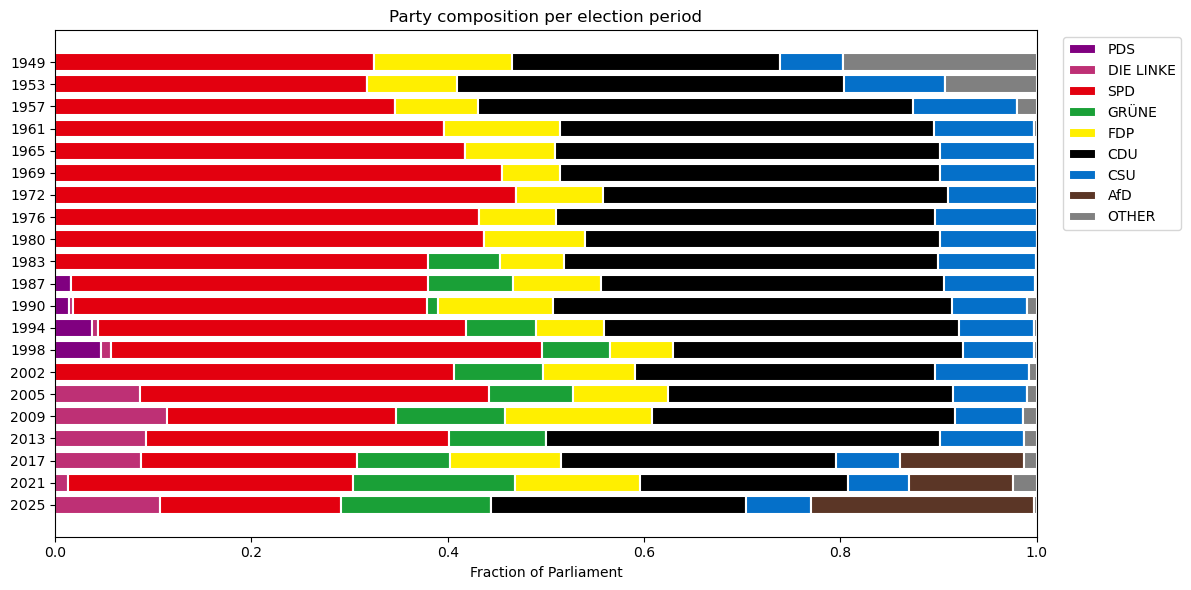

In [6]:
# Normalizing rows to 1:
fractions_norm = fractions.div(fractions.sum(axis=1).replace({0:1}), axis=0)
wps = fractions_norm.index.tolist()
y_pos = np.arange(len(wps))

# Plot as 100% stacked bar chart:
fig, ax = plt.subplots(figsize=(12, max(6, int(len(wps)*0.25))))
left = np.zeros(len(wps))
for i in range(len(PARTY_ORDER)):
    vals = fractions_norm[PARTY_ORDER[i]].values
    ax.barh(terms_df['election_y_str'], vals, left=left, color=PARTY_COLOURS[i], edgecolor='white', linewidth=1.5)
    left = left + vals
ax.set_xlabel('Fraction of Parliament')
ax.set_title('Party composition per election period')
ax.set_xlim(0,1)
ax.invert_yaxis()
ax.legend(PARTY_ORDER, bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

## 3. Gender compositions

We show gender compositions as a ratio of male versus non-male MDBs, where a ratio of 0 means equal representation. To not give a false impression of time, we plot years continous on x, while marking each election on the line to maintain precision.

In [7]:
def get_gender_ratio(df):
    """
    Weighted gender ratio: -1 = all male, 0 = 50/50, 1 = all female.
    :param df: DataFrame with 'Gender' and 'Frac_of_WP' columns.
    :return: float in [-1, 1]
    """
    weights = df.groupby('Gender')['Frac_of_WP'].sum()
    return 2 * (weights.get('female', 0) / weights.sum() - 0.5)

def create_gender_df(group):
    """
    Computes the gender ratio for each subgroup, merged with election year info.
    :param group: str: name of the group to compute the gender ratio for.
    :return: pd.DataFrame with columns ['WP', 'election_y_str', 'Gender_ratio']
    """
    gender_ratio = (
        wp_df
        .groupby(group)
        .apply(get_gender_ratio, include_groups=False)
        .rename('gender_ratio')
        .reset_index()
    )
    return safe_merge(terms_df[['WP', 'election_y_int']], gender_ratio, ['WP'])

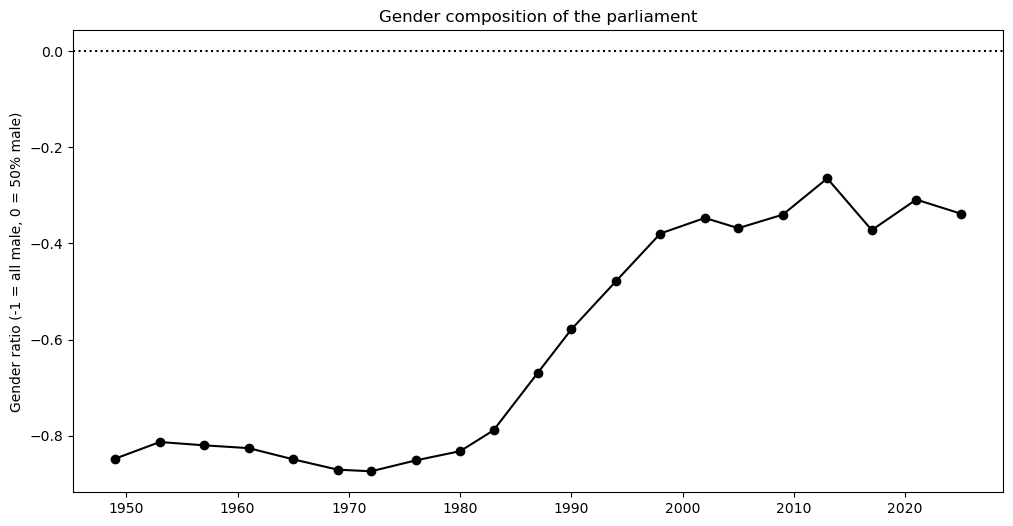

In [8]:
wp_gender_df = create_gender_df(['WP'])

fig, ax = plt.subplots(figsize=(12, max(6, int(len(wp_gender_df)*0.25))))
ax.axhline(0, color="black", linestyle=':')
ax.plot(wp_gender_df['election_y_int'], wp_gender_df['gender_ratio'], marker='o', color='black')
ax.set_ylabel('Gender ratio (-1 = all male, 0 = 50% male)')
ax.set_title('Gender composition of the parliament')
plt.show()

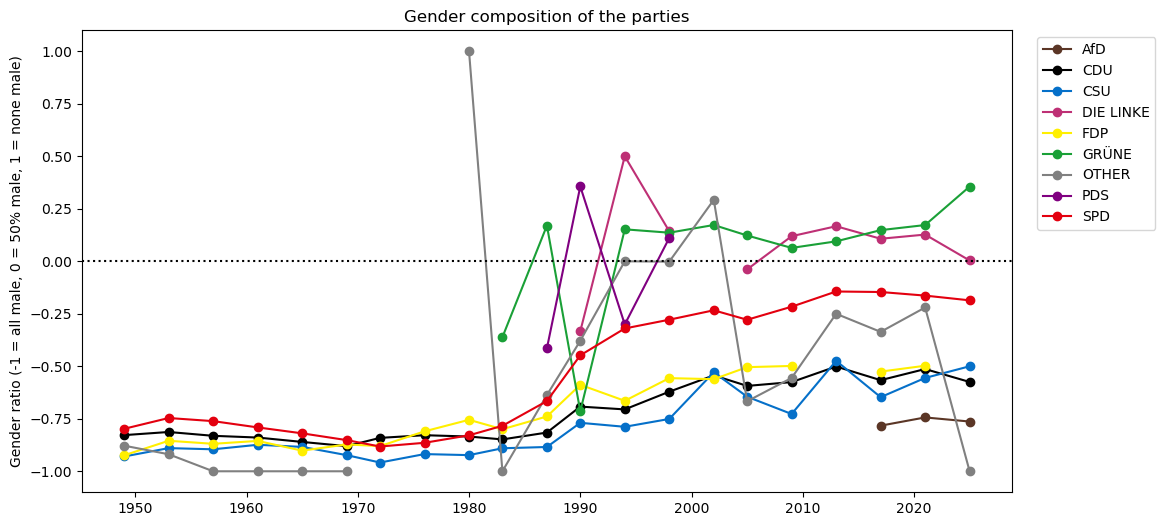

In [9]:
wp_parties_df = create_gender_df(['WP', 'Party'])

fig, ax = plt.subplots(figsize=(12, max(6, int(terms_df.shape[0] * 0.25))))

for party, group in wp_parties_df.groupby('Party'):
    group_full = (
        terms_df
        .merge(group[['WP', 'gender_ratio']], on='WP', how='left')
    )   # Reindex to the full terms range; missing terms become NaN and break the line.

    ax.plot(
        group_full['election_y_int'],
        group_full['gender_ratio'],
        marker='o',
        label=party,
        color=PARTY_DICT.get(party)
    )

ax.set_ylabel('Gender ratio (-1 = all male, 0 = 50% male, 1 = none male)')
ax.set_title('Gender composition of the parties')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.axhline(0, color='black', linestyle=':')
plt.show()

## 4.1 Electionwise correlations of age, party and gender

We define age as the MDB's age when entering parliament. The following two plots show one WP at a time with the option to choose WP interactively. This creates a detailed picture of the mutual relations between our three variables and allows a in-depth analysis of those.

In [10]:
def compute_box_stats(values):
    """
    Prepare stats for a classic boxplot.
    :param values:
    :return: dict with 5 keys: 'med', 'q1', 'q3', 'whislo', 'whishi', 'fliers'
    """
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    median = values.median()
    iqr = q3 - q1

    lower_fence = q1 - 3/2 * iqr
    upper_fence = q3 + 3/2 * iqr

    whislo = values[values >= lower_fence].min()
    whishi = values[values <= upper_fence].max()

    fliers = values[(values < lower_fence) | (values > upper_fence)].tolist()

    return {
        'med': median,
        'q1': q1,
        'q3': q3,
        'whislo': whislo,
        'whishi': whishi,
        'fliers': fliers
    }

# Adding age column:
wp_df['Age'] = (
    (wp_df['MDBWP_FROM'] - wp_df['Date_of_birth']).dt.days // 365.25
).astype(int)

# Creating dict and list for efficient interactive plotting:
wp_to_year = terms_df.set_index('WP')['election_y_str'].to_dict()
wp_options = sorted(wp_df['WP'].unique())
default_wp = max(wp_options)

def plot_interactive(plot_funct):
    """
    Uses the variables created above (wp_to_year, wp_options, default_wp) to create an interactive plot,
    making all WPs accessible via a dropdown menu.
    :param plot_funct: function that takes wp as only argument and creates a plot.
    """
    widgets.interact(
        plot_funct,
        wp=widgets.Dropdown(
            options=[(wp_to_year[wp], wp) for wp in wp_options],
            value=default_wp,
            description='Election:'
        )
    )

In [11]:
# Fixed y-axis ranges across all WPs, so they don't rescale when switching elections:
age_min_all, age_max_all = wp_df['Age'].min(), wp_df['Age'].max()
age_pad = (age_max_all - age_min_all) * 0.05
age_ylim = (age_min_all - age_pad, age_max_all + age_pad)
gender_ylim = (-1.05, 1.05)

def plot_age_v_party(wp):
    """
    Interactive plot of age and gender composition by party.
    :param wp: int: number of the WP to plot
    """
    current_wp = wp_df[wp_df['WP'] == wp]
        # Get wp_df entry of the current WP.
    present_parties = [party for party in PARTY_ORDER if party in current_wp['Party'].unique()]
        # Check which parties are present in the current WP.
    labels = present_parties + ['Overall']

    stats = []
    # Get stats for each party:
    for party in present_parties:
        vals = current_wp.loc[current_wp['Party'] == party, 'Age']
        age_stats = compute_box_stats(vals)
        age_stats['label'] = party
        stats.append(age_stats)

    # Get overall stats:
    overall_stats = compute_box_stats(current_wp['Age'])
    overall_stats['label'] = 'Overall'
    stats.append(overall_stats)

    # Get gender ratios:
    gender_map = (
        wp_parties_df[wp_parties_df['WP'] == wp]
        .set_index('Party')['gender_ratio']
        .to_dict()
    )
    gender_values = [gender_map.get(p, np.nan) for p in present_parties]
    gender_values.append(get_gender_ratio(current_wp))

    fig, ax_age = plt.subplots(figsize=(13, 6))

    ax_gender = ax_age.twinx()
        # Create a second axis for gender ratios.
    positions = range(1, len(stats) + 1)
        # Positions for the ticks on the x-axis.

    # Plotting the boxplots:
    bxp_dict = ax_age.bxp(
        stats,
        positions=positions,
        patch_artist=True,
        widths=0.5,
        showfliers=True,
        medianprops={'color': 'black'},
        flierprops={'marker': 'x', 'markersize': 3}
    )

    # Coloring the boxes according to party colors:
    for patch, label in zip(bxp_dict['boxes'], labels):
        color = PARTY_DICT.get(label) if label != 'Overall' else 'lightgrey'
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Plotting the gender ratios:
    ax_gender.scatter(
        positions,
        gender_values,
        color='white',
        edgecolor='black',
        s=80
    )

    ax_age.set_xticks(positions)
    ax_age.set_xticklabels(labels)
    ax_age.set_ylabel('Age (years)')
    ax_gender.set_ylabel(
        'Gender ratio (-1 = all male, 0 = 50%, 1 = none male)',
        rotation=270,
        labelpad=15
    )
    ax_age.set_ylim(age_ylim)
    ax_gender.set_ylim(gender_ylim)
    ax_age.set_title(f'Age and Gender Composition by Party — Election {wp_to_year[wp]}')

plot_interactive(plot_age_v_party)

plt.show()

interactive(children=(Dropdown(description='Election:', index=20, options=(('1949', np.int64(1)), ('1953', np.…

In [12]:
# Fixed 10-year age bins starting at 15, so x-axis stays consistent across WPs:
age_max_global = int(wp_df['Age'].max() // 10 * 10 + 10)
age_bins = list(range(15, age_max_global + 10, 10))
age_labels = [f'{age_bins[i]}-{age_bins[i+1]-1}' for i in range(len(age_bins) - 1)]

# Adding age groups to wp_df:
wp_df['Age_group'] = pd.cut(
    wp_df['Age'],
    bins=age_bins,
    labels=age_labels,
    right=False
)

# Stacked composition: fraction of each party within each age group per WP
age_groups_df = (
    wp_df
    .groupby(['WP', 'Age_group', 'Party'], observed=True)['Frac_of_WP']
    .sum()
    .reset_index()
)

# Each age group's fraction of parliament per WP
wp_totals = wp_df.groupby('WP')['Frac_of_WP'].sum().rename('wp_total')
age_groups_df = age_groups_df.merge(wp_totals, on='WP')
age_groups_df['fraction'] = age_groups_df['Frac_of_WP'] / age_groups_df['wp_total']

# Gender ratio per age group and WP:
gender_ratio = (
    wp_df
    .groupby(['WP', 'Age_group'], observed=True)
    .apply(get_gender_ratio, include_groups=False)
    .rename('gender_ratio')
    .reset_index()
)
age_groups_df = safe_merge(age_groups_df, gender_ratio, ['WP', 'Age_group'])

In [13]:
# Fixed axis ranges (constant across WPs):
frac_ylim = (0, age_groups_df.groupby(['WP', 'Age_group'])['fraction'].sum().max() * 1.1)
gender_ylim = (-1.05, 1.05)

def plot_age_groups(wp):
    """
    Interactive plot of party and gender composition by age group.
    Similar mechanisms to plot_age_v_party.
    :param wp: int: number of the WP to plot
    """
    current_wp = age_groups_df[age_groups_df['WP'] == wp]

    fig, ax_frac = plt.subplots(figsize=(12, 6))
    ax_gender = ax_frac.twinx()
    bottom = pd.Series(0.0, index=age_labels)

    # Stacking up party fractions to create bars:
    for i in range(len(PARTY_ORDER)):
        party_data = (
            current_wp[current_wp['Party'] == PARTY_ORDER[i]]
            .set_index('Age_group')['fraction']
            .reindex(age_labels, fill_value=0)
        )
        ax_frac.bar(
            age_labels,
            party_data,
            bottom=bottom,
            color=PARTY_COLOURS[i],
            alpha=0.7,
            label=PARTY_ORDER[i],
            width=0.6,
            edgecolor='black',
            linewidth=1.2
        )
        bottom += party_data

    # Plot gender ratio per age group (one value per age group, not per party)
    gender_per_group = (
        current_wp
        .drop_duplicates(subset='Age_group')
        .set_index('Age_group')['gender_ratio']
        .reindex(age_labels)
    )
    ax_gender.scatter(
        age_labels,
        gender_per_group,
        color='white',
        edgecolors='black',
        s=80,
        label='Gender ratio'
    )

    ax_frac.set_ylim(frac_ylim)
    ax_gender.set_ylim(gender_ylim)
    ax_frac.set_ylabel('Fraction of parliament')
    ax_gender.set_ylabel(
        'Gender ratio (-1 = all male, 0 = 50%, 1 = none male)',
        rotation=270,
        labelpad=15
    )
    ax_frac.set_xlabel('Age group (years)')
    ax_frac.set_title(f'Age groups — Election {wp_to_year[wp]}')
    ax_frac.legend(bbox_to_anchor=(1.12, 1), loc='upper left')

plot_interactive(plot_age_groups)

plt.show()

interactive(children=(Dropdown(description='Election:', index=20, options=(('1949', np.int64(1)), ('1953', np.…

## 4.2 Trends in party, age and gender
The following plots give an overview about the development of the parliaments composition over time.

In [14]:
# A group is considered dominant if it combines at least 5% of the parliament by age group and gender.
size_bins = [
    (0.05, 0.10, 50),
    (0.10, 0.15, 100),
    (0.15, np.inf, 200)
]

def share_to_size(share):
    """
    Convert a share (fraction of parliament) to a marker size for plotting.
    :param share: float: fraction of parliament
    :return: int: marker size
    """
    for lo, hi, size in size_bins:
        if lo <= share < hi:
            return size

def weighted_quantile(values, weights, q):
    """

    :param values:
    :param weights:
    :param q:
    :return:
    """
    sorter = np.argsort(values)
    values = np.array(values)[sorter]
    weights = np.array(weights)[sorter]
    cum_weights = np.cumsum(weights) - 0.5 * weights
    cum_weights /= np.sum(weights)
    return np.interp(q, cum_weights, values)

def age_summary(g):
    """

    :param g:
    :return:
    """
    mean_age = (g['Age'] * g['Frac_of_WP']).sum() / g['Frac_of_WP'].sum()
    q1 = weighted_quantile(g['Age'], g['Frac_of_WP'], 0.25)
    q3 = weighted_quantile(g['Age'], g['Frac_of_WP'], 0.75)
    return pd.Series({'mean_age': mean_age, 'age_q1': q1, 'age_q3': q3})

# Creating df to plot overall mean age per WP:
overall_mean_age = (
    wp_df
    .groupby('WP')
    .apply(age_summary, include_groups=False)
    .reset_index()
    .merge(terms_df[['WP', 'election_y_int']], on='WP')
    .sort_values('WP')
)
# Calculate the numbers of MDBs in the WP x gender x age groups:
plot_df = (
    wp_df
    .groupby(['WP', 'Age_group', 'Gender'], observed=True)['Frac_of_WP']
    .sum()
    .reset_index()
)

# Turning sums into fractions:
wp_totals = pd.DataFrame(wp_df.groupby('WP')['Frac_of_WP'].sum().rename('wp_total'))
plot_df = safe_merge(plot_df, wp_totals, ['WP'])
plot_df['share'] = plot_df['Frac_of_WP'] / plot_df['wp_total']

# Keeping only dominant groups:
plot_df = plot_df[plot_df['share'] >= 0.05]
plot_df['size'] = plot_df['share'].apply(share_to_size)

# Adding term info:
plot_df = safe_merge(plot_df, terms_df, ['WP'])

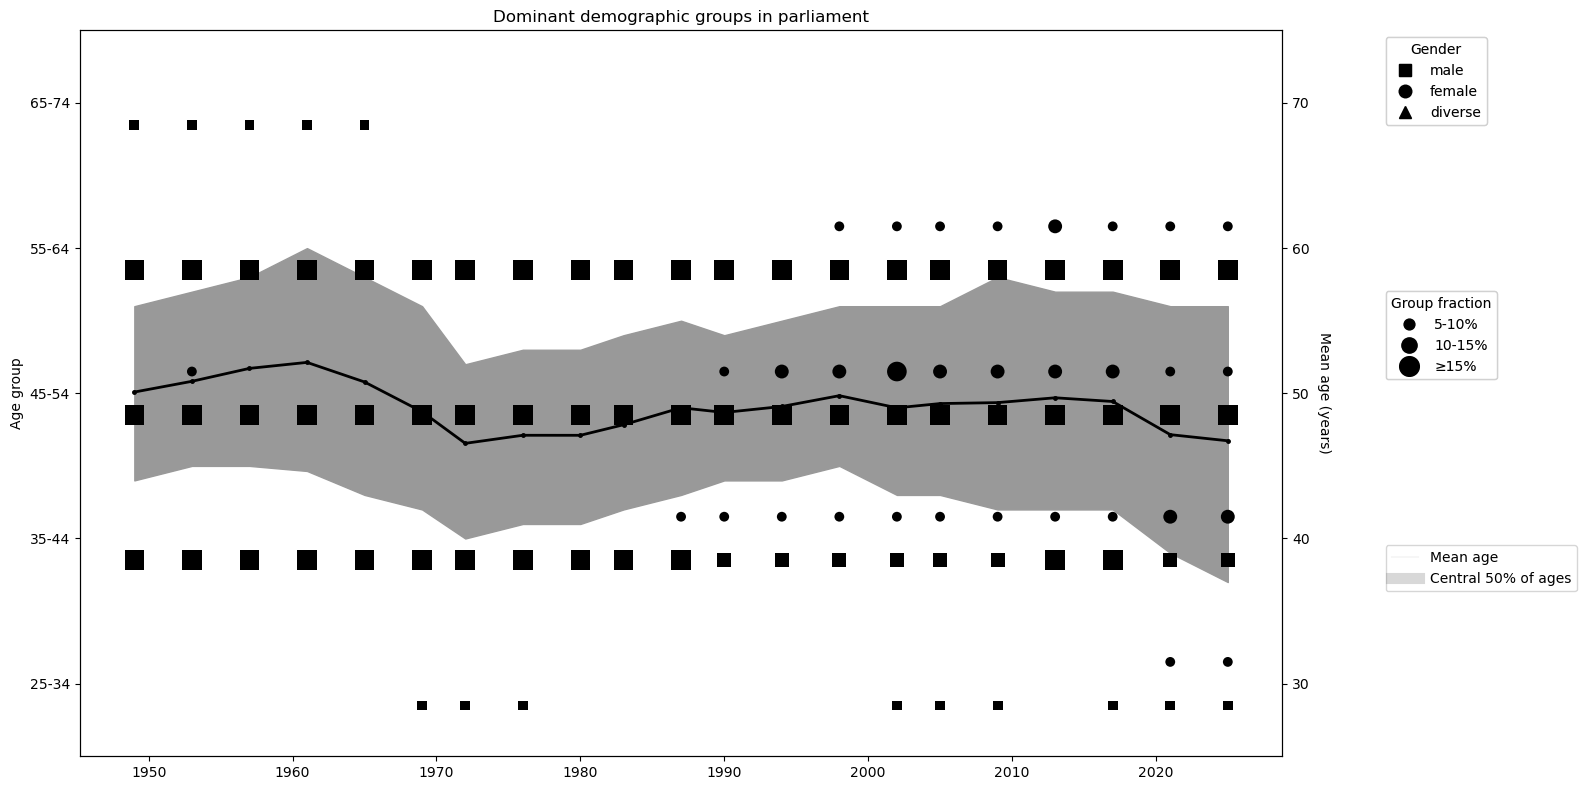

In [15]:
# Only include age groups that actually have at least one dominant point:
used_age_labels = [label for label in age_labels if label in plot_df['Age_group'].unique()]
age_group_to_y = {label: i for i, label in enumerate(used_age_labels)}
plot_df['y_pos'] = (plot_df['Age_group'].map(age_group_to_y).astype(float)
                    + plot_df['Gender'].map(GENDER_OFFSETS).astype(float))

# y-axis limits adjusted to dominant groups only:
used_indices = [age_labels.index(label) for label in used_age_labels]
used_age_min = age_bins[min(used_indices)]
used_age_max = age_bins[max(used_indices) + 1]

plot_df['x_pos'] = plot_df['election_y_int']

fig, ax = plt.subplots(figsize=(16, 8))
ax_age = ax.twinx()

# Make sure zorder works on both axes:
ax.set_zorder(ax_age.get_zorder() + 1)
ax.patch.set_visible(False)

# Plotting genders separately:
for gender, marker in GENDER_MARKERS.items():
    current_gender = plot_df[plot_df['Gender'] == gender]
    ax.scatter(
        current_gender['x_pos'],
        current_gender['y_pos'],
        s=current_gender['size'],
        color='black',
        marker=marker,
        edgecolors='none',
        zorder=3
    )

# Plot mean 50% of ages as envelope:
ax_age.fill_between(
    overall_mean_age['election_y_int'],
    overall_mean_age['age_q1'],
    overall_mean_age['age_q3'],
    color=DEFAULT_SHADES[1],
    zorder=1
)

# Plotting mean age as line:
ax_age.plot(
    overall_mean_age['election_y_int'],
    overall_mean_age['mean_age'],
    color='black',
    linewidth=2,
    marker='.',
    markersize=5,
    zorder=2
)


ax.set_yticks(range(len(used_age_labels)))
ax.set_yticklabels(used_age_labels)
ax.set_ylim(-0.5, len(used_age_labels) - 0.5)
ax.set_ylabel('Age group')
ax_age.set_ylim(used_age_min, used_age_max)
ax_age.set_ylabel('Mean age (years)', rotation=270, labelpad=15)
ax.set_title('Dominant demographic groups in parliament')

# Legends:
gender_legend = [
    Line2D([0], [0], marker=marker, color='black', linestyle='', markersize=9, label=gender)
    for gender, marker in GENDER_MARKERS.items()
]
size_legend = [
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=np.sqrt(60), label='5-10%'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=np.sqrt(120), label='10-15%'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=np.sqrt(200), label='≥15%')
]
mean_age_legend = [
    Line2D([0], [0], color='black', linewidth=0.05, label='Mean age'),
    Line2D([0], [0], color='grey', linewidth=8, alpha=0.3, label='Central 50% of ages')
]

legend1 = ax.legend(handles=gender_legend, title='Gender', loc='upper left', bbox_to_anchor=(1.08, 1))
ax.add_artist(legend1)
legend2 = ax.legend(handles=size_legend, title='Group fraction', loc='upper left', bbox_to_anchor=(1.08, 0.65))
ax.add_artist(legend2)
ax.legend(handles=mean_age_legend, loc='upper left', bbox_to_anchor=(1.08, 0.3))
ax.add_artist(legend1)
ax.add_artist(legend2)

plt.tight_layout()
plt.show()

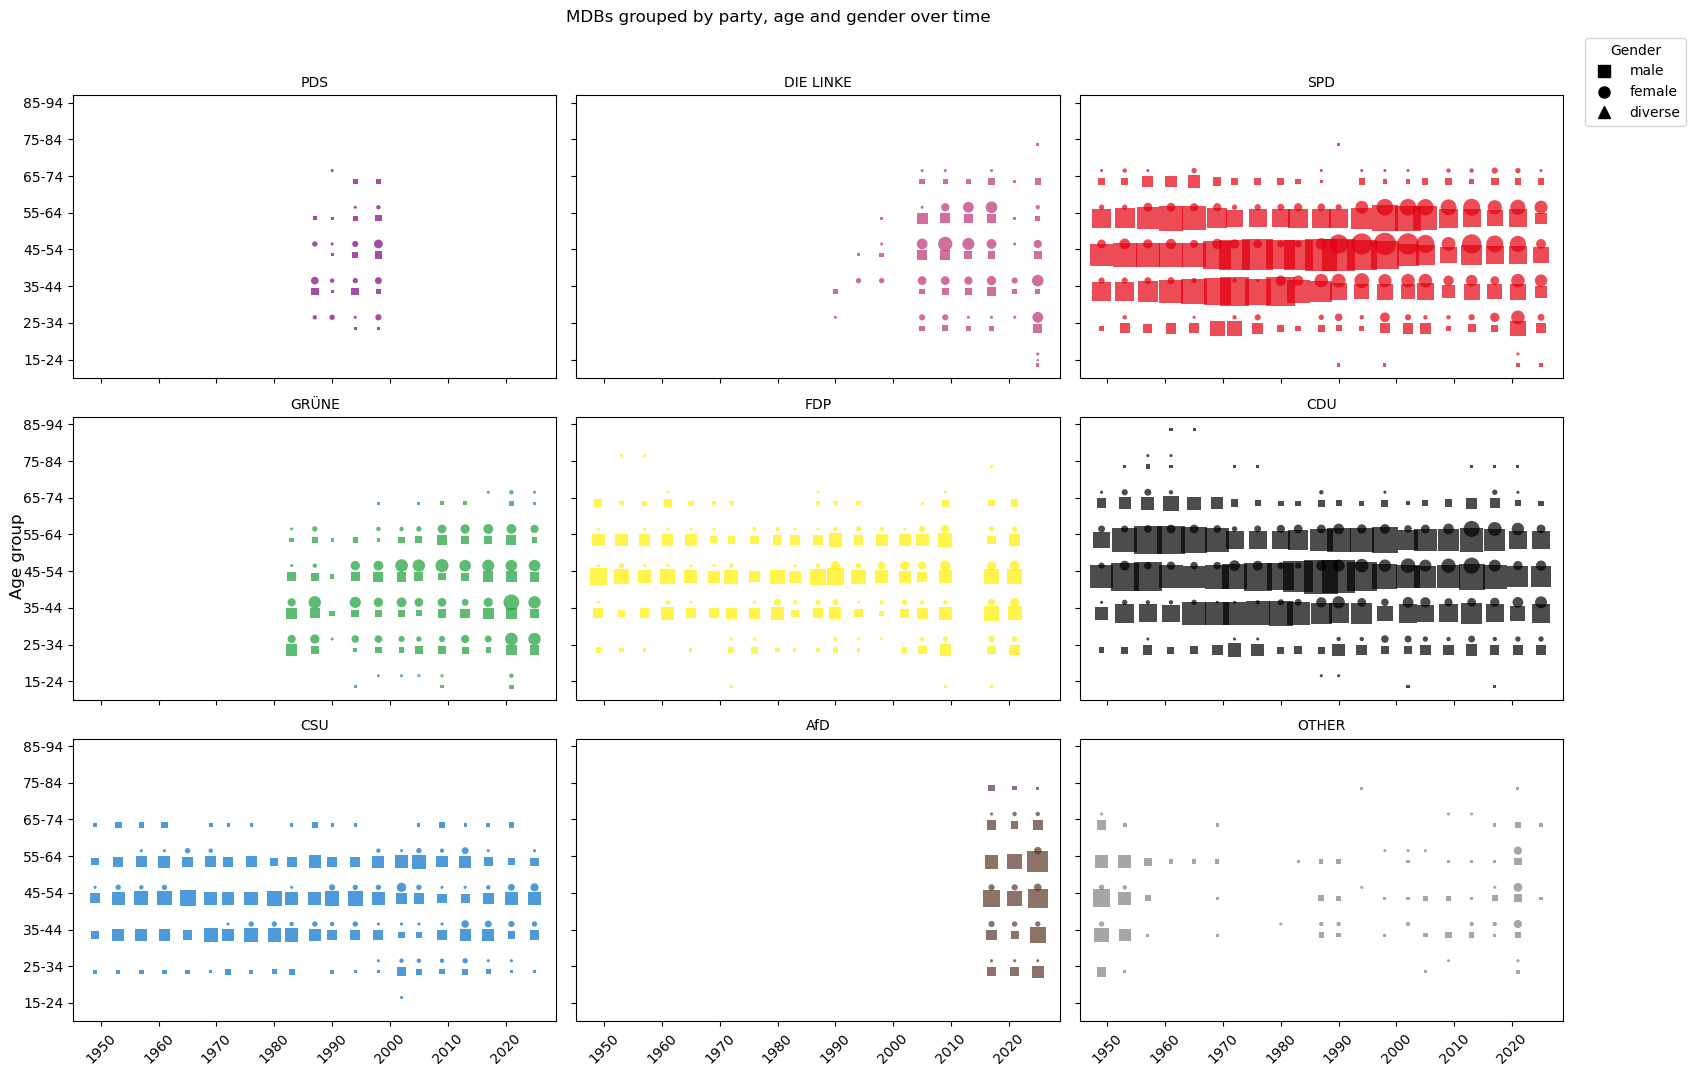

In [16]:
parties = [p for p in PARTY_ORDER if p in wp_df['Party'].unique()]
n_cols, n_rows = 3, 3

# Creating a copy of wp_df to avoid adding only plot relevant variations to the original:
plot_df = wp_df.copy()

# Mapping age groups to y-axis positions:
age_group_to_y = {label: i for i, label in enumerate(age_labels)}
plot_df['y_pos'] = plot_df['Age_group'].map(age_group_to_y).astype(float)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5), sharex=True, sharey=True)
axes = axes.flatten()

# Plotting each party separately:
for i, party in enumerate(parties):
    ax = axes[i]
    current_party = plot_df[plot_df['Party'] == party]
    color = PARTY_COLOURS[i]

    # Plotting each gender separately:
    for gender, marker in GENDER_MARKERS.items():
        current_gender = current_party[current_party['Gender'] == gender]

        # Counting MDBs in age x party x gender groups:
        counts = (
            current_gender
            .groupby(['election_y_int', 'y_pos'])
            .size()
            .reset_index(name='count')
        )

        # Plotting the counts:
        ax.scatter(
            counts['election_y_int'],
            counts['y_pos'] + GENDER_OFFSETS[gender],
            s=(counts['count']) * 5,
            color=color,
            marker=marker,
            alpha=0.7,
            edgecolors='none'
        )

    ax.set_title(party, fontsize=10)
    ax.tick_params(axis='x', rotation=45)

#
ax_ref = axes[0]
ax_ref.set_yticks(range(len(age_labels)))
ax_ref.set_yticklabels(age_labels)

# Hide unused subplots:
for j in range(len(parties), len(axes)):
    axes[j].set_visible(False)

# Shared legend for gender:
gender_legend = [
    Line2D([0], [0], marker=marker, color='black', linestyle='', markersize=8, label=gender)
    for gender, marker in GENDER_MARKERS.items()
]
fig.legend(handles=gender_legend, title='Gender', loc='upper left', bbox_to_anchor=(1.0, 1))

fig.suptitle('MDBs grouped by party, age and gender over time', y=1.02)
fig.supylabel('Age group')
plt.tight_layout()
plt.show()

## 5. Prevalence of academic titles
We show the data on a non manipulated scale to make proportions easy to understand. To maintain the possibility of exact interpretation we annotated the results.

In [17]:
def find_turning_points(y):
    """
    A turning point is an index i at which y[i] is strictly more extreme than both neighbors.
    :param y: list: y-values
    :return: list: indices of turning points
    """
    idx = []
    for i in range(1, len(y) - 1):
        if (y[i] > y[i-1] and y[i] > y[i+1]) or (y[i] < y[i-1] and y[i] < y[i+1]):
            idx.append(i)
    return idx

def plot_stacked_share(cat_col, title, category_order):
    """
    Stacked area plot of the share of categories in cat_col over time.
    Cat_col must be a column in wp_df that has exactly 3 categories.
    This function uses terms_df.
    :param cat_col: str: column name in wp_df
    :param title: str: plot title
    :param category_order: list: the 3 categories, ordered top to bottom in the plot
    """
    figsize = (12, 6)
    title_x_gap_frac = 0.05
    thin_band_frac = 0.06
    collision_offset_pts = -15
    middle_title_y_offset_pts = 15
    ylabel = 'Share of parliament'

    # Stacked composition: fraction of each category within each WP
    weight = (
        wp_df
        .groupby(['WP', cat_col], observed=True)['Frac_of_WP']
        .sum()
        .unstack(fill_value=0)
    )
    share = weight.div(weight.sum(axis=1), axis=0)

    # categories are stacked bottom-to-top by stackplot, so reverse category_order
    # (top-to-bottom as given) to get the bottom-to-top plotting order
    categories = list(reversed(category_order))

    shades = {cat: DEFAULT_SHADES[i] for i, cat in enumerate(categories)}
    text_colors = {cat: DEFAULT_TEXT_COLORS[i] for i, cat in enumerate(categories)}

    plot_df = safe_merge(share, terms_df, ['WP']).sort_values('election_y_int')
    x = plot_df['election_y_int'].values
    ys = [plot_df[cat].values for cat in categories]

    fig, ax = plt.subplots(figsize=figsize)

    # Colored stacked areas (lowest zorder)
    ax.stackplot(
        x,
        ys,
        colors=[shades[cat] for cat in categories],
        edgecolor='black',
        linewidth=0.5,
        zorder=1
    )

    # Gridlines in front of the colored areas
    ax.grid(True, axis='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.6, zorder=2)
    ax.set_axisbelow(False)

    # Cumulative boundaries (needed to locate band centers)
    cum = np.zeros(len(x))
    boundaries = [cum.copy()]
    for y in ys:
        cum = cum + y
        boundaries.append(cum.copy())

    # Boundary markers on top of grid
    for b in boundaries[1:-1]:
        ax.plot(x, b, color='black', linewidth=0.5, marker='o', markersize=4,
                 linestyle='none', zorder=3)

    x_range = x.max() - x.min()
    mid_idx = len(x) // 2
    mid_x = x[mid_idx]

    # Turning-point labels: own share of each category, centered in band,
    # offset down if colliding with area title or a thin band
    for cat, y, lower, upper in zip(categories, ys, boundaries[:-1], boundaries[1:]):
        for i in find_turning_points(y):
            band_center = (lower[i] + upper[i]) / 2
            band_thickness = upper[i] - lower[i]

            if abs(x[i] - mid_x) < title_x_gap_frac * x_range:
                continue
            thin_band = band_thickness < thin_band_frac
            y_offset = collision_offset_pts if thin_band else 0
            ax.annotate(
                f'{y[i]*100:.1f}%',
                xy=(x[i], band_center),
                xytext=(0, y_offset),
                textcoords='offset points',
                ha='center',
                va='center',
                fontsize=8,
                color=text_colors[cat],
                zorder=4
            )

    # Category labels inside each band (standard position, mid x)
    # Middle (2nd) category gets an upward offset to avoid overlap
    cum_bottom = 0
    for idx, (cat, y) in enumerate(zip(categories, ys)):
        band_center = cum_bottom + y[mid_idx] / 2
        y_title_offset = middle_title_y_offset_pts if idx == 1 else 0
        ax.annotate(
            cat,
            xy=(mid_x, band_center),
            xytext=(0, y_title_offset),
            textcoords='offset points',
            ha='center', va='center',
            fontsize=11, color=text_colors[cat], fontweight='bold',
            zorder=4
        )
        cum_bottom += y[mid_idx]

    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    ax.set_title(title)
    ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

    return fig, ax

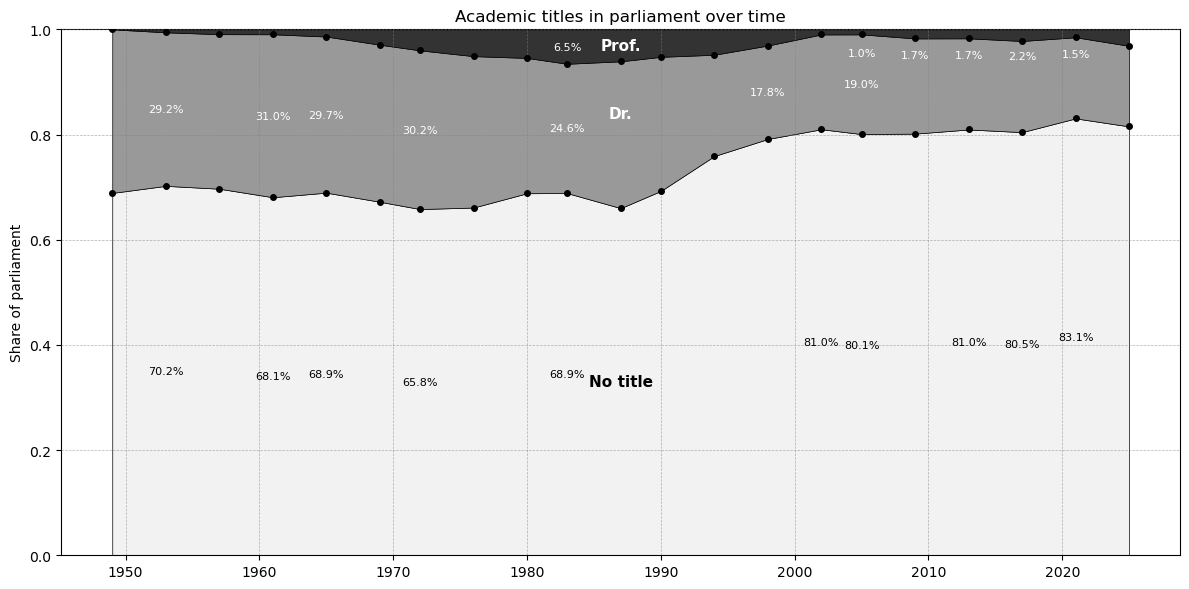

In [18]:
plot_stacked_share('Acad_Title', 'Academic titles in parliament over time', ['Prof.', 'Dr.', 'No title'])

plt.show()

## 6. Time and terms served by MDBs
The duration of service of MDBs is shown both in years and in terms, which does make a significant difference as can be seen below. The data can be interpreted with reference to party affiliation but both plots describe the overall trend in parliament as well.

In [19]:
# Summing up total duration served as MDB.
# Handling open-ended terms (MDBWP_UNTIL is NaT) by treating them as ending today.
term_end = wp_df['MDBWP_UNTIL'].fillna(TODAY)
term_duration_days = (term_end - wp_df['MDBWP_FROM']).dt.days

total_duration = (
    wp_df
    .assign(term_duration_days=term_duration_days)
    .groupby('ID')['term_duration_days']
    .sum()
    .rename('Total_duration_days')
    .reset_index()
)
mdb_df = safe_merge(mdb_df, total_duration, ['ID'] )

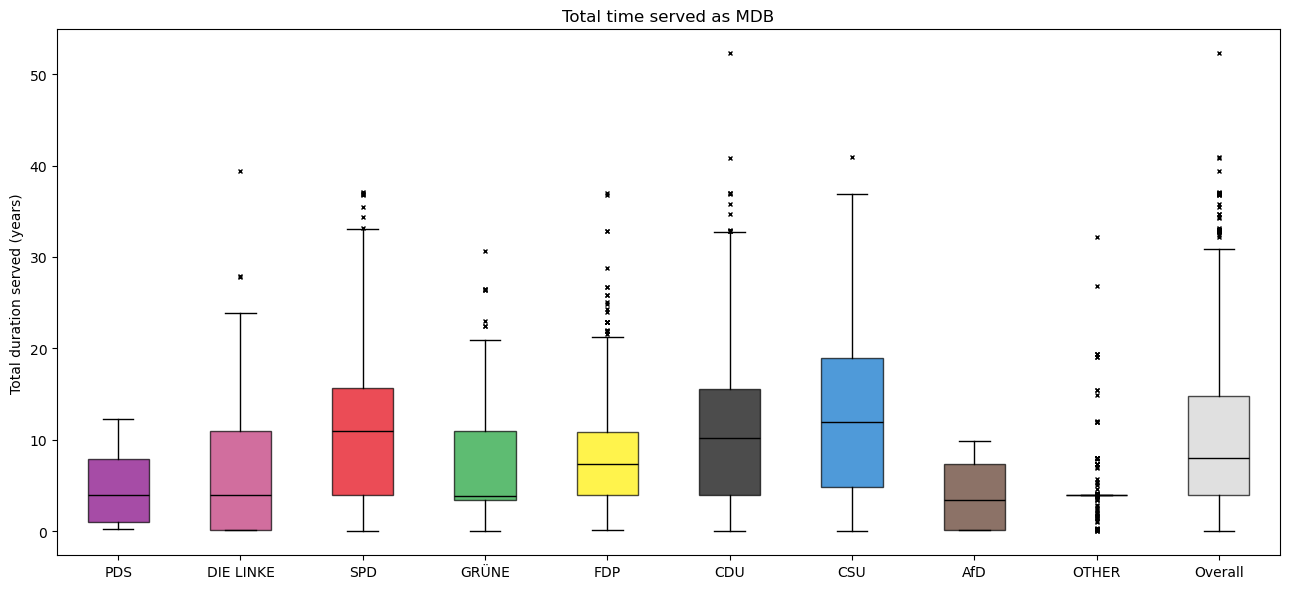

In [20]:
# Calculating duration in years:
duration_df = (
    mdb_df
    .dropna(subset=['Total_duration_days'])
    .assign(Total_duration_years=lambda d: d['Total_duration_days'] / 365.25)
)

party_order_dur = [p for p in PARTY_ORDER if p in duration_df['Party'].unique()]
labels_dur = party_order_dur + ['Overall']

# Getting boxplot stats for each party:
stats_dur = []
for party in party_order_dur:
    vals = duration_df.loc[duration_df['Party'] == party, 'Total_duration_years']
    s = compute_box_stats(vals)
    s['label'] = party
    stats_dur.append(s)

# Getting stats for overall boxplot:
overall_dur_stats = compute_box_stats(duration_df['Total_duration_years'])
overall_dur_stats['label'] = 'Overall'
stats_dur.append(overall_dur_stats)

fig, ax = plt.subplots(figsize=(13, 6))
positions = range(1, len(stats_dur) + 1)

# Plot Boxplot:
bxp_dict = ax.bxp(
    stats_dur,
    positions=positions,
    patch_artist=True,
    widths=0.5,
    showfliers=True,
    medianprops={'color': 'black'},
    flierprops={'marker': 'x', 'markersize': 3, 'alpha': 1}
)

# Colour coding:
for patch, label in zip(bxp_dict['boxes'], labels_dur):
    color = PARTY_DICT.get(label, 'lightgrey') if label != 'Overall' else 'lightgrey'
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(labels_dur)
ax.set_ylabel('Total duration served (years)')
ax.set_title('Total time served as MDB')
plt.tight_layout()
plt.show()

In [21]:
def round_with_threshold(x):
    """
    Custom rounding function to check if a full term is served or not.
    A full term is defined as a term that is served for at least 90% of the duration.
    This prevents us from being affected by small inaccuracies in the data.
    :param x: float: the value to round
    :return: rounded value
    """
    floor_val = np.floor(x)
    frac = x - floor_val
    return floor_val + 1 if frac >= 0.9 else floor_val

def bin_terms(n):
    """
    Choose correct bin for number of served terms.
    :param n: number of full terms served
    :return: corresponding bin
    """
    if n < 1:
        return '<1'
    elif n >= 8:
        return '>=8'
    else:
        return str(int(n))

# Summing up Frac_of_WP per ID, then rounding down with a 0.9 threshold:
frac_sum = wp_df.groupby('ID')['Frac_of_WP'].sum()
full_terms = pd.DataFrame(frac_sum.apply(round_with_threshold).astype(int).rename('full_terms'))

# Store in mdb_df, keyed by ID:
mdb_df = safe_merge(mdb_df, full_terms, ['ID'])

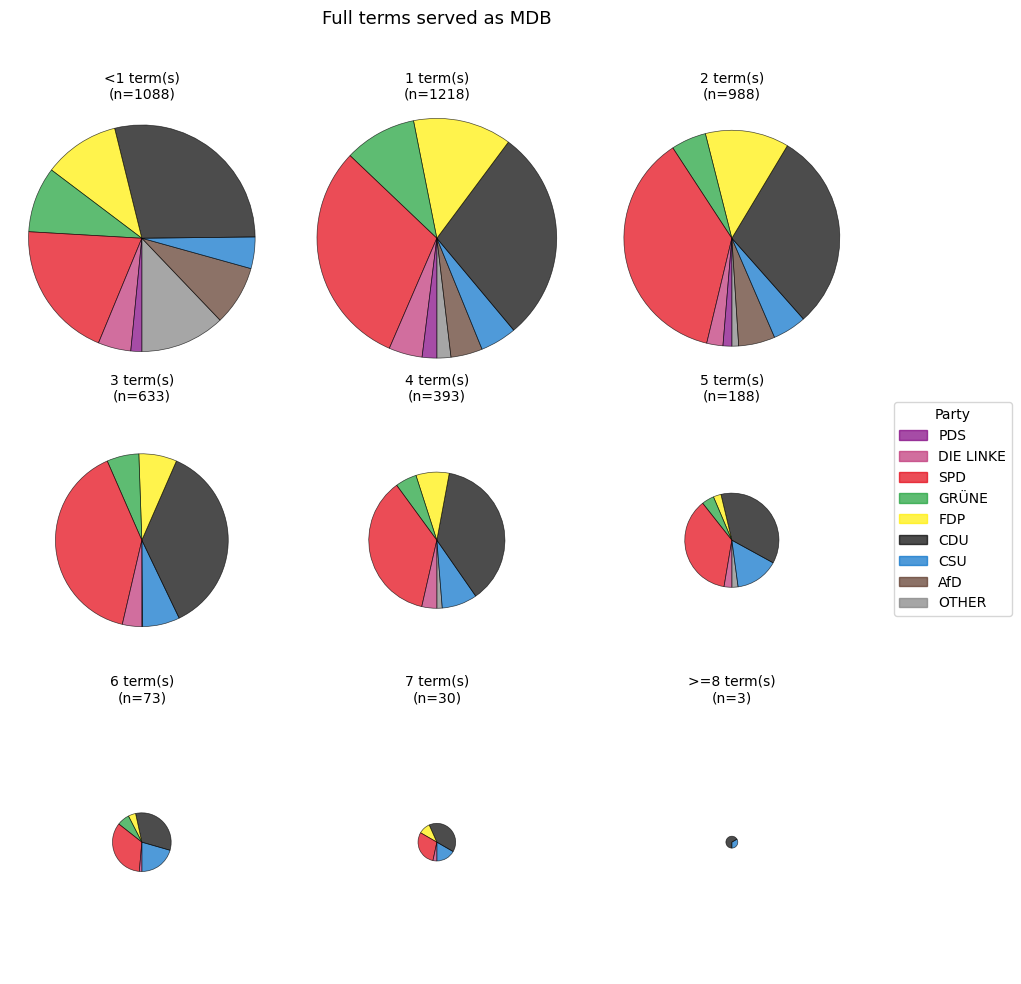

In [22]:

# Reverse party order for the plot:
party_order = [p for p in PARTY_ORDER if p in mdb_df['Party'].unique()]
party_order_rev = list(reversed(party_order))

# Creating bins:
bin_labels = ['<1', '1', '2', '3', '4', '5', '6', '7', '>=8']
mdb_df['term_bin'] = mdb_df['full_terms'].apply(bin_terms)

pivot = (
    mdb_df
    .groupby(['term_bin', 'Party'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=bin_labels, fill_value=0)
    .reindex(columns=party_order_rev, fill_value=0)
)

totals = pivot.sum(axis=1)
active_bins = [b for b in bin_labels if totals[b] > 0]

n = len(active_bins)
ncols = 3
nrows = int(np.ceil(n / ncols))
max_total = totals.max()
max_radius = 1.0

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3.2 * nrows))
axes = np.atleast_1d(axes).flatten()

# Plotting each bin:
for ax, term_bin in zip(axes, active_bins):
    counts = pivot.loc[term_bin]
    counts = counts[counts > 0]
    total = totals[term_bin]
    radius = max_radius * np.sqrt(total / max_total)

    # Plotting pie chart:
    ax.pie(
        counts.values,
        colors=[PARTY_DICT[p] for p in counts.index],
        radius=radius,
        startangle=270,
        wedgeprops=dict(edgecolor='black', linewidth=0.5, alpha=0.7)
    )
    ax.set_title(f'{term_bin} term(s)\n(n={int(total)})', fontsize=10)
    ax.set_xlim(-max_radius * 1.1, max_radius * 1.1)
    ax.set_ylim(-max_radius * 1.1, max_radius * 1.1)

for ax in axes[n:]:
    ax.axis('off')

handles = [plt.Rectangle((0, 0), 1, 1, color=PARTY_DICT[p], alpha=0.7) for p in party_order]
fig.legend(handles, party_order, title='Party', loc='center left', bbox_to_anchor=(1.0, 0.5))

fig.suptitle('Full terms served as MDB', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Marital status of MDBs

Not much code here due to reusibility of the functions from 5. Same philosophy here.

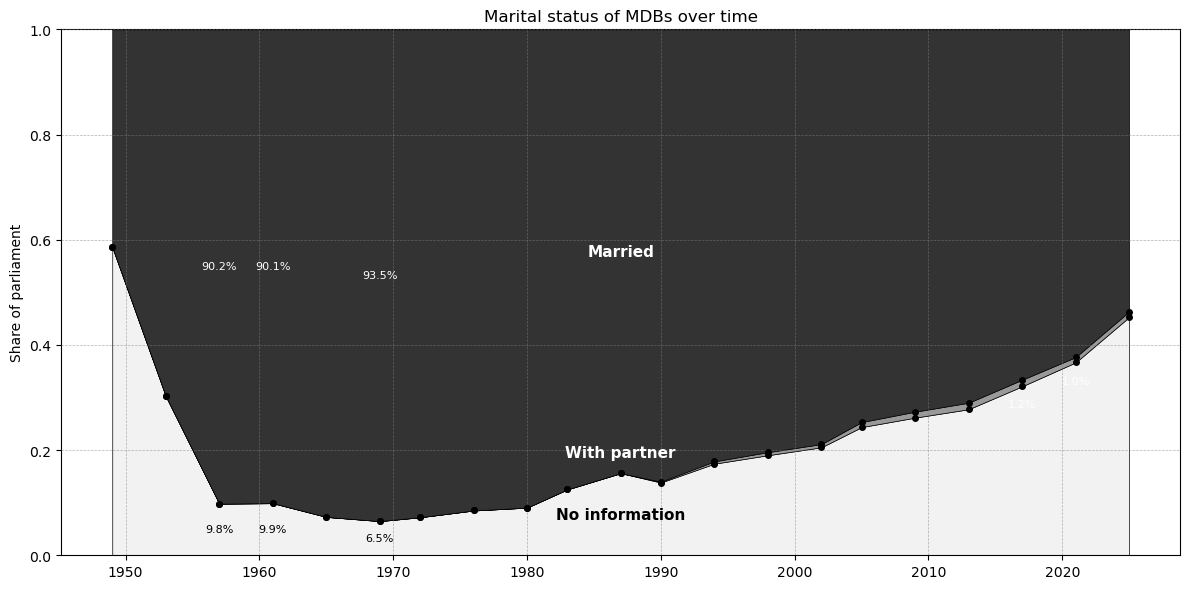

In [23]:
plot_stacked_share('Marital_status', 'Marital status of MDBs over time', ['Married', 'With partner', 'No information'])

plt.show()

## 8. Number of children of MDBs
We choose to split the chart to give a clear view of the effect of gender and of the data's distribution.

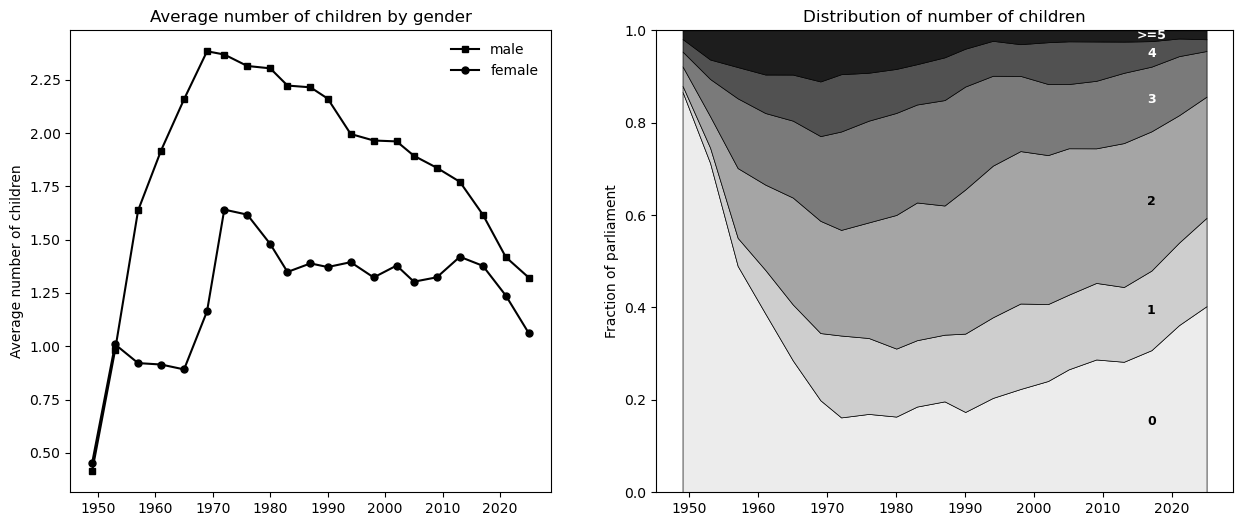

In [24]:
figsize = (15, 6)
ylabel = 'Fraction of parliament'

# Creating a copy of wp_df to avoid adding only plot relevant variations:
plot_df = wp_df.copy()

# Computing weighted average number of children:
mean_children = (
    plot_df
    .groupby(['WP', 'Gender'], observed=True)
    .apply(
        lambda g: np.average(
            g['Children'],
            weights=g['Frac_of_WP']
        ),
        include_groups=False
    )
    .rename('mean_children')
    .reset_index()
)

mean_children = safe_merge(
    mean_children,
    terms_df[['WP', 'election_y_int']],
    ['WP']
)

# Grouping numbers of children:
plot_df['Children_group'] = plot_df['Children'].clip(upper=5)
plot_df['Children_group'] = (
    plot_df['Children_group']
    .replace({5: '>=5'})
)

children_order = list(range(5)) + ['>=5']

# Computing fractions of parliament:
weight = (
    plot_df
    .groupby(['WP', 'Children_group'], observed=True)['Frac_of_WP']
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=children_order, fill_value=0)
)

share = weight.div(weight.sum(axis=1), axis=0)

share = (
    safe_merge(
        share,
        terms_df[['WP', 'election_y_int']],
        ['WP']
    )
    .sort_values('election_y_int')
)

fig, (ax_children, ax_share) = plt.subplots(
    1,
    2,
    figsize=figsize,
    gridspec_kw={'width_ratios': [1, 1.2]}
)

# Plotting average number of children:
for gender, marker in [
    ('male', 's'),
    ('female', 'o')
]:

    current_gender = (
        mean_children[mean_children['Gender'] == gender]
        .sort_values('election_y_int')
    )

    ax_children.plot(
        current_gender['election_y_int'],
        current_gender['mean_children'],
        color='black',
        linewidth=1.5,
        marker=marker,
        markersize=5,
        label=gender
    )

ax_children.set_ylabel('Average number of children')
ax_children.set_title('Average number of children by gender')
ax_children.legend(frameon=False)

# Plotting stacked fractions:
x = share['election_y_int'].values
ys = [share[group].values for group in children_order]

colors = plt.cm.Greys(np.linspace(0.15, 0.9, len(children_order)))

ax_share.stackplot(
    x,
    ys,
    colors=colors,
    edgecolor='black',
    linewidth=0.5
)

# Annotating stacked areas:
label_pos = -3
cum = np.zeros(len(x))

for i, group in enumerate(children_order):

    lower = cum
    upper = cum + ys[i]
    middle = (lower + upper) / 2

    text_color = 'white' if group in [3, 4, '>=5'] else 'black'

    ax_share.text(
        x[label_pos],
        middle[label_pos],
        str(group),
        ha='center',
        va='center',
        fontsize=9,
        color=text_color,
        fontweight='bold'
    )

    cum = upper

ax_share.set_ylim(0, 1)
ax_share.set_ylabel(ylabel)
ax_share.set_title('Distribution of number of children')


plt.show()